In [5]:
"""
================================================================================
🚀 PROFESSIONAL DATA CLEANING PORTFOLIO PROJECT
================================================================================
Author: Muhammad Umer Khayam Adrees
Date: December 2025
GitHub: https://github.com/umer-khayam
LinkedIn: https://www.linkedin.com/in/muhammad-umer-khayam-adrees-5785291a5?utm_source=share_via&utm_content=profile&utm_medium=member_ios
================================================================================
🎯 BUSINESS CASE: Telecom Customer Churn Analysis
📊 Dataset: Synthetic telecom customer data (5,000 records)
⚙️ Skills: Data Cleaning, EDA, Feature Engineering, Visualization
================================================================================
"""

print("🎯 PROFESSIONAL DATA CLEANING PORTFOLIO PROJECT")
print("=" * 70)
print("📋 Project initialized successfully!")
print("📅 Date:", pd.Timestamp.now().strftime('%B %d, %Y'))
print("=" * 70)

🎯 PROFESSIONAL DATA CLEANING PORTFOLIO PROJECT
📋 Project initialized successfully!
📅 Date: December 05, 2025


In [6]:
# ============================================================
# 📦 PACKAGE INSTALLATION & IMPORT
# ============================================================

print("📦 Setting up environment...")
print("-" * 50)

# Install required packages (run only once)
import sys
!{sys.executable} -m pip install pandas numpy matplotlib seaborn --quiet

# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set professional display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', 1000)
pd.set_option('display.float_format', '{:.2f}'.format)

# Set visualization style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

print("✅ Packages imported successfully!")
print(f"📊 Pandas version: {pd.__version__}")
print(f"📈 NumPy version: {np.__version__}")
print(f"🎨 Matplotlib version: {plt.matplotlib.__version__}")
print("=" * 70)

📦 Setting up environment...
--------------------------------------------------
✅ Packages imported successfully!
📊 Pandas version: 2.3.3
📈 NumPy version: 2.3.5
🎨 Matplotlib version: 3.10.7


In [7]:
# ============================================================
# 📊 SYNTHETIC DATASET GENERATION
# ============================================================

print("🔄 Generating professional telecom customer dataset...")
print("-" * 50)

# Set seed for reproducibility
np.random.seed(42)

# Number of customers
n_customers = 5000

print(f"Creating {n_customers:,} customer records...")

# Generate realistic telecom data
customer_data = {
    'customer_id': [f'CUST{str(i).zfill(6)}' for i in range(1, n_customers + 1)],
    'age': np.clip(np.random.normal(45, 15, n_customers).astype(int), 18, 80),
    'gender': np.random.choice(['Male', 'Female'], n_customers, p=[0.52, 0.48]),
    'city': np.random.choice(['New York', 'Los Angeles', 'Chicago', 'Houston', 'Phoenix', 'Miami'], n_customers),
    'tenure_months': np.clip(np.random.exponential(30, n_customers).astype(int), 1, 72),
    'contract_type': np.random.choice(['Monthly', 'One Year', 'Two Year'], n_customers, p=[0.55, 0.30, 0.15]),
    'internet_service': np.random.choice(['DSL', 'Fiber', 'None'], n_customers, p=[0.40, 0.45, 0.15]),
    'phone_service': np.random.choice(['Yes', 'No'], n_customers, p=[0.85, 0.15]),
    'monthly_charges': np.clip(np.random.normal(65, 20, n_customers), 20, 150),
    'total_charges': np.abs(np.random.normal(2000, 1000, n_customers)),
    'customer_service_calls': np.random.poisson(2, n_customers),
    'satisfaction_score': np.random.randint(1, 11, n_customers),
    'payment_method': np.random.choice(['Credit Card', 'Bank Transfer', 'E-Check', 'Mail Check'], n_customers),
    'paperless_billing': np.random.choice(['Yes', 'No'], n_customers, p=[0.70, 0.30]),
    'churn': np.random.choice([0, 1], n_customers, p=[0.73, 0.27])
}

# Create DataFrame
df = pd.DataFrame(customer_data)

# Add calculated column
df['total_charges'] = df['monthly_charges'] * df['tenure_months'] + np.random.normal(0, 100, n_customers)
df['total_charges'] = df['total_charges'].abs()

print("✅ Dataset created successfully!")
print(f"📊 Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print("=" * 70)

🔄 Generating professional telecom customer dataset...
--------------------------------------------------
Creating 5,000 customer records...
✅ Dataset created successfully!
📊 Shape: 5,000 rows × 15 columns


In [8]:
# ============================================================
# 🎭 INTRODUCE REALISTIC DATA QUALITY ISSUES
# ============================================================

print("🎭 Adding realistic data quality challenges...")
print("-" * 50)

# Store original for comparison
df_original = df.copy()

# 1. Add missing values (5-15% in key columns)
cols_with_missing = ['satisfaction_score', 'city', 'payment_method']
for col in cols_with_missing:
    missing_mask = np.random.rand(n_customers) < 0.1
    df.loc[missing_mask, col] = np.nan
    print(f"   • Added missing values to '{col}': {missing_mask.sum():,} records")

# 2. Add outliers (2% of records)
outlier_mask = np.random.rand(n_customers) < 0.02
df.loc[outlier_mask, 'monthly_charges'] = df.loc[outlier_mask, 'monthly_charges'] * 3
df.loc[outlier_mask, 'total_charges'] = df.loc[outlier_mask, 'total_charges'] * 5
print(f"   • Added outliers to financial columns: {outlier_mask.sum():,} records")

# 3. Add duplicates (1% duplicates)
dup_indices = np.random.choice(n_customers, size=int(n_customers * 0.01), replace=False)
df = pd.concat([df, df.iloc[dup_indices]], ignore_index=True)
print(f"   • Added duplicate records: {len(dup_indices):,} records")

# 4. Inconsistent formatting
df.loc[np.random.rand(len(df)) < 0.05, 'gender'] = 'male'
df.loc[np.random.rand(len(df)) < 0.05, 'gender'] = 'FEMALE'
df.loc[np.random.rand(len(df)) < 0.05, 'city'] = 'new york'
print(f"   • Added inconsistent text formatting")

print("\n📊 DATASET WITH QUALITY ISSUES:")
print(f"• Total records: {len(df):,}")
print(f"• Missing values: {df.isnull().sum().sum():,}")
print(f"• Duplicate rows: {df.duplicated().sum():,}")
print("=" * 70)

🎭 Adding realistic data quality challenges...
--------------------------------------------------
   • Added missing values to 'satisfaction_score': 487 records
   • Added missing values to 'city': 470 records
   • Added missing values to 'payment_method': 509 records
   • Added outliers to financial columns: 99 records
   • Added duplicate records: 50 records
   • Added inconsistent text formatting

📊 DATASET WITH QUALITY ISSUES:
• Total records: 5,050
• Missing values: 1,451
• Duplicate rows: 37


In [9]:
# ============================================================
# 🔍 INITIAL DATA ASSESSMENT
# ============================================================

print("📋 COMPREHENSIVE DATA ASSESSMENT")
print("=" * 70)

print("1. 📊 DATASET OVERVIEW")
print("-" * 40)
print(f"• Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"• Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

print("\n2. 🔤 DATA TYPES")
print("-" * 40)
dtype_summary = df.dtypes.value_counts()
for dtype, count in dtype_summary.items():
    print(f"• {str(dtype):20}: {count} columns")

print("\n3. 📉 MISSING VALUES ANALYSIS")
print("-" * 40)
missing_summary = df.isnull().sum()
missing_pct = (missing_summary / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing_summary,
    'Missing %': missing_pct
}).sort_values('Missing %', ascending=False)

print(missing_df[missing_df['Missing Count'] > 0].to_string())

print("\n4. 👀 DATA PREVIEW")
print("-" * 40)
print("First 3 rows:")
print(df.head(3).to_string())
print("\nLast 3 rows:")
print(df.tail(3).to_string())
print("=" * 70)

📋 COMPREHENSIVE DATA ASSESSMENT
1. 📊 DATASET OVERVIEW
----------------------------------------
• Shape: 5,050 rows × 15 columns
• Memory usage: 2.35 MB

2. 🔤 DATA TYPES
----------------------------------------
• object              : 8 columns
• int64               : 3 columns
• float64             : 3 columns
• int32               : 1 columns

3. 📉 MISSING VALUES ANALYSIS
----------------------------------------
                    Missing Count  Missing %
payment_method                517      10.24
satisfaction_score            492       9.74
city                          442       8.75

4. 👀 DATA PREVIEW
----------------------------------------
First 3 rows:
  customer_id  age gender         city  tenure_months contract_type internet_service phone_service  monthly_charges  total_charges  customer_service_calls  satisfaction_score payment_method paperless_billing  churn
0  CUST000001   52   Male  Los Angeles              1      One Year            Fiber           Yes            74.7

📊 CREATING DATA QUALITY VISUALIZATION DASHBOARD


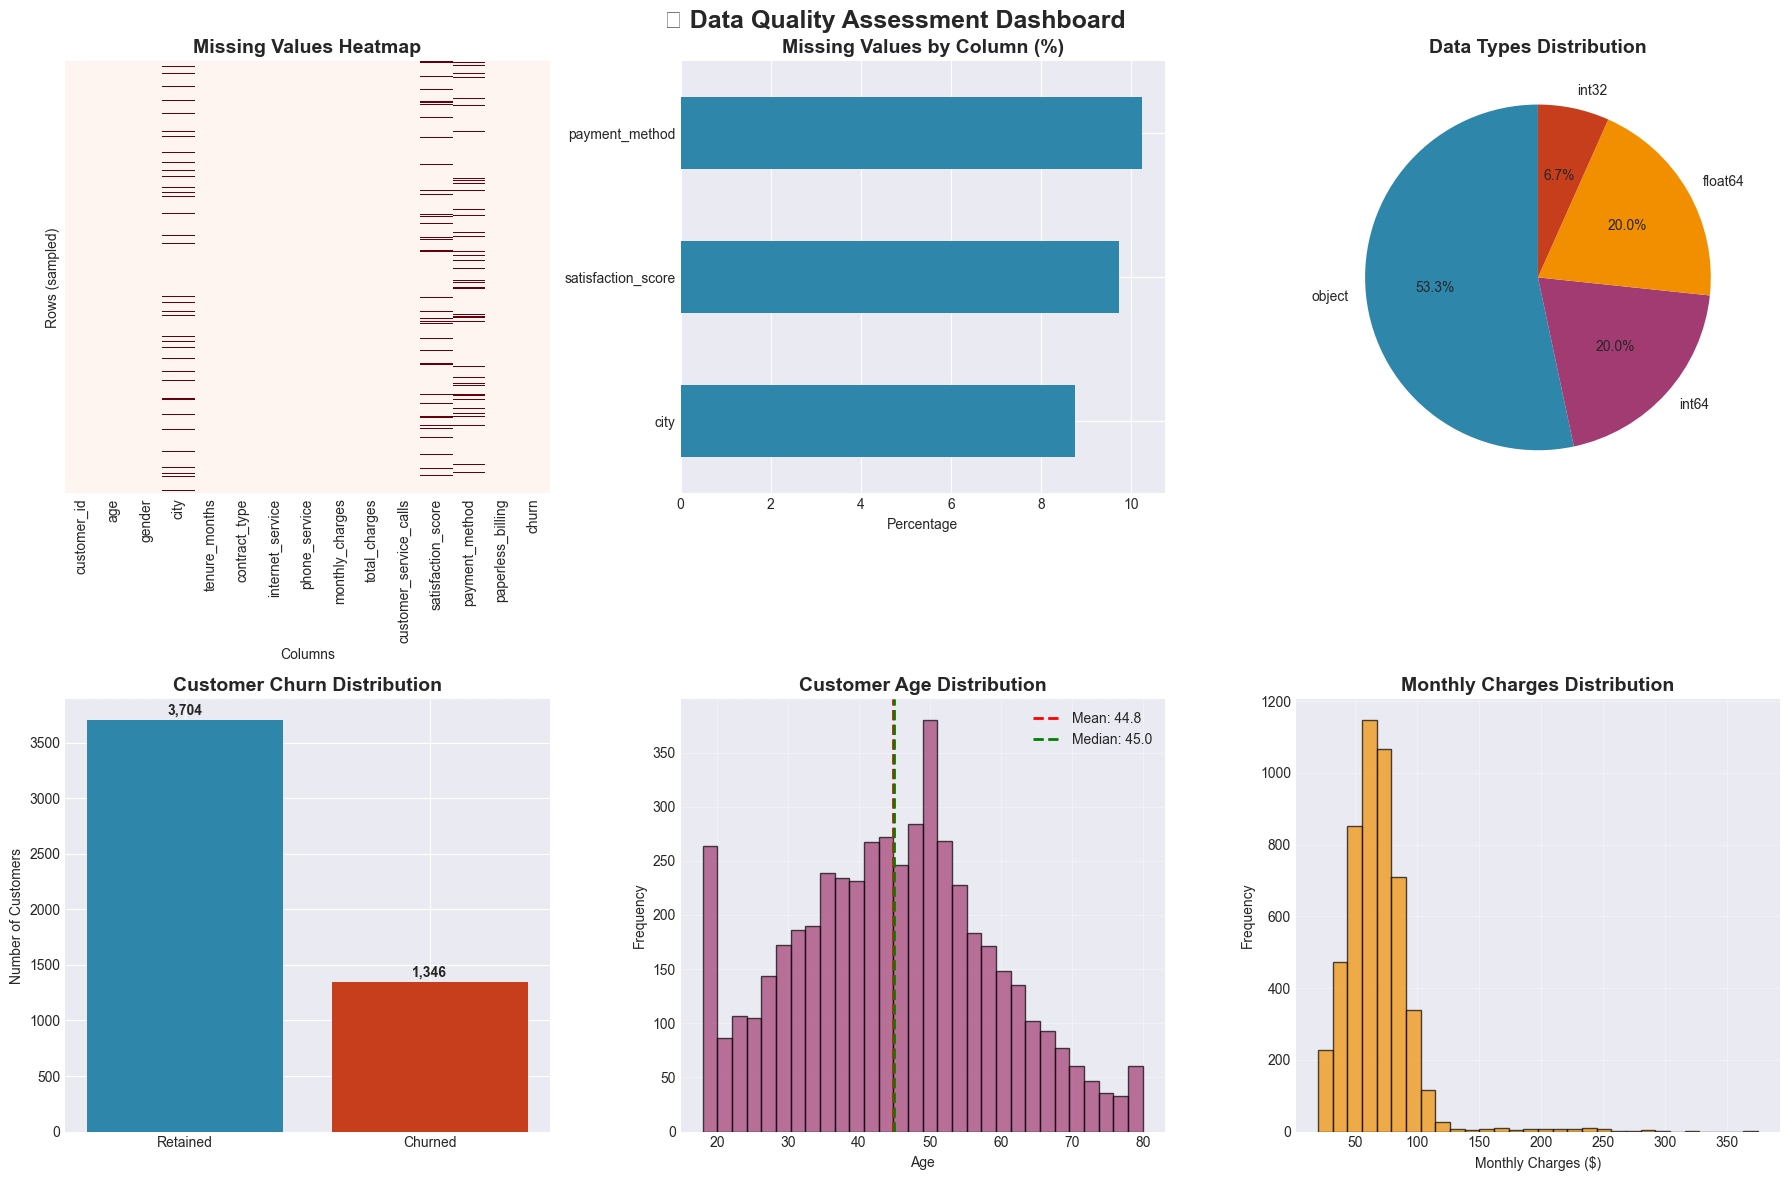

✅ Visual dashboard created successfully!


In [10]:
# ============================================================
# 📈 VISUAL DATA QUALITY DASHBOARD
# ============================================================

print("📊 CREATING DATA QUALITY VISUALIZATION DASHBOARD")
print("=" * 70)

# Define professional color palette
colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#6B8F71']

# Create figure
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 1. Missing Values Heatmap
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, 
            cmap='Reds', ax=axes[0, 0])
axes[0, 0].set_title('Missing Values Heatmap', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Columns')
axes[0, 0].set_ylabel('Rows (sampled)')

# 2. Missing Values Percentage
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_pct = missing_pct[missing_pct > 0]
if len(missing_pct) > 0:
    missing_pct.sort_values().plot(kind='barh', ax=axes[0, 1], color=colors[0])
    axes[0, 1].set_title('Missing Values by Column (%)', fontsize=14, fontweight='bold')
    axes[0, 1].set_xlabel('Percentage')
else:
    axes[0, 1].text(0.5, 0.5, 'No Missing Values!', 
                    ha='center', va='center', fontsize=16, fontweight='bold')
    axes[0, 1].set_title('Missing Values Analysis', fontsize=14, fontweight='bold')

# 3. Data Types Distribution
dtype_counts = df.dtypes.value_counts()
axes[0, 2].pie(dtype_counts.values, labels=dtype_counts.index, 
               autopct='%1.1f%%', colors=colors[:len(dtype_counts)], startangle=90)
axes[0, 2].set_title('Data Types Distribution', fontsize=14, fontweight='bold')

# 4. Churn Distribution
churn_counts = df['churn'].value_counts()
axes[1, 0].bar(['Retained', 'Churned'], churn_counts.values, 
               color=[colors[0], colors[3]])
axes[1, 0].set_title('Customer Churn Distribution', fontsize=14, fontweight='bold')
axes[1, 0].set_ylabel('Number of Customers')
for i, v in enumerate(churn_counts.values):
    axes[1, 0].text(i, v + 50, f'{v:,}', ha='center', fontweight='bold')

# 5. Age Distribution
axes[1, 1].hist(df['age'].dropna(), bins=30, edgecolor='black', 
                color=colors[1], alpha=0.7)
axes[1, 1].axvline(df['age'].mean(), color='red', linestyle='--', 
                   linewidth=2, label=f'Mean: {df["age"].mean():.1f}')
axes[1, 1].axvline(df['age'].median(), color='green', linestyle='--', 
                   linewidth=2, label=f'Median: {df["age"].median():.1f}')
axes[1, 1].set_title('Customer Age Distribution', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Age')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

# 6. Monthly Charges Distribution
axes[1, 2].hist(df['monthly_charges'].dropna(), bins=30, edgecolor='black', 
                color=colors[2], alpha=0.7)
axes[1, 2].set_title('Monthly Charges Distribution', fontsize=14, fontweight='bold')
axes[1, 2].set_xlabel('Monthly Charges ($)')
axes[1, 2].set_ylabel('Frequency')
axes[1, 2].grid(True, alpha=0.3)

plt.suptitle('📊 Data Quality Assessment Dashboard', fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()

print("✅ Visual dashboard created successfully!")
print("=" * 70)

In [13]:
# ============================================================
# ⚙️ PROFESSIONAL DATA CLEANING PIPELINE (CORRECTED)
# ============================================================

print("🔧 INITIALIZING PROFESSIONAL CLEANING PIPELINE")
print("=" * 70)

class DataCleaningPipeline:
    """
    Professional data cleaning pipeline with logging and validation.
    Demonstrates industry-standard data cleaning practices.
    """
    
    def __init__(self, dataframe):
        """Initialize pipeline with data"""
        self.df = dataframe.copy()
        self.original_shape = dataframe.shape
        self.cleaning_log = []
        self.missing_before = dataframe.isnull().sum().sum()
        self.duplicates_before = dataframe.duplicated().sum()
        print(f"📦 Pipeline initialized with {self.original_shape[0]:,} rows × {self.original_shape[1]} columns")
    
    def log_operation(self, operation, details):
        """Log cleaning operations for documentation"""
        import datetime
        self.cleaning_log.append({
            'timestamp': datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
            'operation': operation,
            'details': details,
            'shape': self.df.shape
        })
    
    def handle_missing_values(self):
        """Professional missing value treatment"""
        print("\n🔄 Step 1: Handling missing values...")
        
        if self.missing_before > 0:
            # Numeric columns: fill with median
            numeric_cols = self.df.select_dtypes(include=[np.number]).columns
            for col in numeric_cols:
                if self.df[col].isnull().any():
                    median_val = self.df[col].median()
                    self.df[col] = self.df[col].fillna(median_val)
            
            # Categorical columns: fill with mode
            categorical_cols = self.df.select_dtypes(include=['object']).columns
            for col in categorical_cols:
                if self.df[col].isnull().any():
                    mode_val = self.df[col].mode()[0] if not self.df[col].mode().empty else 'Unknown'
                    self.df[col] = self.df[col].fillna(mode_val)
            
            missing_after = self.df.isnull().sum().sum()
            self.log_operation('missing_values', {
                'before': self.missing_before,
                'after': missing_after,
                'reduction': self.missing_before - missing_after
            })
            print(f"   ✅ Missing values reduced: {self.missing_before:,} → {missing_after:,}")
        else:
            print("   ✅ No missing values found")
        
        return self.df
    
    def remove_duplicates(self):
        """Remove duplicate records"""
        print("\n🔄 Step 2: Removing duplicates...")
        
        if self.duplicates_before > 0:
            self.df = self.df.drop_duplicates()
            duplicates_after = self.df.duplicated().sum()
            self.log_operation('remove_duplicates', {
                'before': self.duplicates_before,
                'after': duplicates_after,
                'removed': self.duplicates_before - duplicates_after
            })
            print(f"   ✅ Duplicates removed: {self.duplicates_before:,} → {duplicates_after:,}")
        else:
            print("   ✅ No duplicates found")
        
        return self.df
    
    def handle_outliers(self):
        """Detect and cap outliers using IQR method"""
        print("\n🔄 Step 3: Handling outliers...")
        numeric_cols = self.df.select_dtypes(include=[np.number]).columns
        
        outlier_report = []
        for col in numeric_cols:
            if col == 'churn':  # Skip target variable
                continue
                
            # Calculate IQR
            Q1 = self.df[col].quantile(0.25)
            Q3 = self.df[col].quantile(0.75)
            IQR = Q3 - Q1
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR
            
            # Count outliers
            outliers = ((self.df[col] < lower_bound) | (self.df[col] > upper_bound)).sum()
            
            if outliers > 0:
                # Cap outliers
                self.df[col] = self.df[col].clip(lower_bound, upper_bound)
                outlier_report.append({
                    'column': col,
                    'outliers_treated': outliers,
                    'percentage': f"{(outliers/len(self.df))*100:.1f}%"
                })
        
        if outlier_report:
            self.log_operation('handle_outliers', {'report': outlier_report})
            print("   📋 Outlier treatment report:")
            for report in outlier_report[:3]:  # Show first 3
                print(f"     • {report['column']}: {report['outliers_treated']} outliers ({report['percentage']})")
        else:
            print("   ✅ No significant outliers found")
        
        return self.df
    
    def standardize_data(self):
        """Standardize data formats and fix inconsistencies"""
        print("\n🔄 Step 4: Standardizing data formats...")
        
        # Standardize text columns
        text_cols = self.df.select_dtypes(include=['object']).columns
        for col in text_cols:
            self.df[col] = self.df[col].astype(str).str.strip().str.title()
        
        # Fix specific columns
        if 'gender' in self.df.columns:
            self.df['gender'] = self.df['gender'].replace({
                'Male': 'Male', 'Female': 'Female',
                'male': 'Male', 'MALE': 'Male',
                'female': 'Female', 'FEMALE': 'Female'
            })
        
        if 'paperless_billing' in self.df.columns:
            self.df['paperless_billing'] = self.df['paperless_billing'].replace({
                'Yes': 'Yes', 'No': 'No',
                'yes': 'Yes', 'YES': 'Yes',
                'no': 'No', 'NO': 'No'
            })
        
        self.log_operation('standardize_data', {'columns_standardized': list(text_cols)})
        print("   ✅ Data formats standardized")
        
        return self.df
    
    def execute_pipeline(self):
        """Execute complete cleaning pipeline"""
        print("\n" + "=" * 70)
        print("🚀 EXECUTING COMPLETE CLEANING PIPELINE")
        print("=" * 70)
        
        print(f"Starting shape: {self.original_shape}")
        
        steps = [
            ("Missing Values", self.handle_missing_values),
            ("Duplicates", self.remove_duplicates),
            ("Outliers", self.handle_outliers),
            ("Standardization", self.standardize_data)
        ]
        
        for step_name, step_func in steps:
            print(f"\n▶ {step_name}:")
            step_func()
            print(f"   Current shape: {self.df.shape}")
        
        print("\n" + "=" * 70)
        print("✅ CLEANING PIPELINE COMPLETE!")
        print("=" * 70)
        
        return self.df
    
    def generate_report(self):
        """Generate professional cleaning report"""
        print("\n📋 CLEANING PROCESS SUMMARY")
        print("-" * 40)
        
        # Get metrics from logs
        missing_after = self.df.isnull().sum().sum()
        duplicates_after = self.df.duplicated().sum()
        
        # Extract removed counts
        missing_removed = self.missing_before - missing_after
        duplicates_removed = self.duplicates_before - duplicates_after
        
        summary_data = {
            'Metric': ['Original Rows', 'Cleaned Rows', 'Rows Removed',
                       'Missing Values Before', 'Missing Values After', 'Missing Values Removed',
                       'Duplicates Before', 'Duplicates After', 'Duplicates Removed'],
            'Value': [
                f"{self.original_shape[0]:,}",
                f"{self.df.shape[0]:,}",
                f"{self.original_shape[0] - self.df.shape[0]:,}",
                f"{self.missing_before:,}",
                f"{missing_after:,}",
                f"{missing_removed:,}",
                f"{self.duplicates_before:,}",
                f"{duplicates_after:,}",
                f"{duplicates_removed:,}"
            ]
        }
        
        summary_df = pd.DataFrame(summary_data)
        print(summary_df.to_string(index=False))
        
        print("\n🔧 Cleaning Operations Performed:")
        operations = set()
        for log in self.cleaning_log:
            operation_name = log['operation'].replace('_', ' ').title()
            operations.add(operation_name)
        
        for op in sorted(operations):
            print(f"  • {op}")
        
        print(f"\n✅ Final Data Quality Score: {self.calculate_quality_score():.1f}/10")
        
        return summary_df
    
    def calculate_quality_score(self):
        """Calculate data quality score (0-10)"""
        score = 10.0
        
        # Deduct for missing values
        missing_pct = (self.df.isnull().sum().sum() / self.df.size) * 100
        if missing_pct > 0:
            score -= min(5, missing_pct * 0.5)
        
        # Deduct for duplicates
        duplicate_pct = (self.df.duplicated().sum() / len(self.df)) * 100
        if duplicate_pct > 0:
            score -= min(3, duplicate_pct * 0.3)
        
        return max(0, score)

print("✅ Professional Data Cleaning Pipeline class ready!")
print("=" * 70)

🔧 INITIALIZING PROFESSIONAL CLEANING PIPELINE
✅ Professional Data Cleaning Pipeline class ready!


In [14]:
# ============================================================
# 🚀 EXECUTE CLEANING PIPELINE (CORRECTED)
# ============================================================

print("🔧 RUNNING DATA CLEANING PIPELINE")
print("=" * 70)

print("📊 INITIAL DATA STATUS:")
print("-" * 40)
print(f"• Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"• Missing values: {df.isnull().sum().sum():,}")
print(f"• Duplicate rows: {df.duplicated().sum():,}")
print(f"• Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

# Initialize pipeline
print("\n🔄 Initializing cleaning pipeline...")
cleaner = DataCleaningPipeline(df)

# Execute all cleaning steps
print("\n🚀 Starting cleaning process...")
df_cleaned = cleaner.execute_pipeline()

# Generate detailed report
print("\n📋 GENERATING CLEANING REPORT")
print("-" * 40)
report = cleaner.generate_report()

print("\n🎯 FINAL RESULTS SUMMARY:")
print("=" * 40)
print(f"📈 DATA QUALITY IMPROVEMENT:")
print(f"   Original → Cleaned")
print(f"   Rows: {df.shape[0]:,} → {df_cleaned.shape[0]:,}")
print(f"   Missing: {df.isnull().sum().sum():,} → {df_cleaned.isnull().sum().sum():,}")
print(f"   Duplicates: {df.duplicated().sum():,} → {df_cleaned.duplicated().sum():,}")

print(f"\n⭐ QUALITY ASSESSMENT:")
quality_score = cleaner.calculate_quality_score()
if quality_score >= 9:
    rating = "⭐⭐⭐⭐⭐ EXCELLENT"
elif quality_score >= 7:
    rating = "⭐⭐⭐⭐ VERY GOOD"
elif quality_score >= 5:
    rating = "⭐⭐⭐ GOOD"
else:
    rating = "⭐⭐ NEEDS IMPROVEMENT"

print(f"   Quality Score: {quality_score:.1f}/10.0")
print(f"   Rating: {rating}")

print(f"\n📊 CLEANED DATA SNAPSHOT:")
print("-" * 40)
print(f"• First 3 rows:")
print(df_cleaned.head(3).to_string())
print(f"\n• Data types:")
for col, dtype in df_cleaned.dtypes.items():
    print(f"  {col:25} → {dtype}")

print(f"\n✅ DATA READY FOR:")
print("-" * 40)
print("  • 📈 Business analysis")
print("  • 🤖 Machine learning")
print("  • 📊 Dashboard creation")
print("  • 📋 Reporting")

print("\n" + "=" * 70)
print("🚀 CLEANING PROCESS COMPLETE - DATA READY FOR ANALYSIS!")
print("=" * 70)

🔧 RUNNING DATA CLEANING PIPELINE
📊 INITIAL DATA STATUS:
----------------------------------------
• Shape: 5,050 rows × 15 columns
• Missing values: 1,451
• Duplicate rows: 37
• Memory usage: 2.35 MB

🔄 Initializing cleaning pipeline...
📦 Pipeline initialized with 5,050 rows × 15 columns

🚀 Starting cleaning process...

🚀 EXECUTING COMPLETE CLEANING PIPELINE
Starting shape: (5050, 15)

▶ Missing Values:

🔄 Step 1: Handling missing values...
   ✅ Missing values reduced: 1,451 → 0
   Current shape: (5050, 15)

▶ Duplicates:

🔄 Step 2: Removing duplicates...
   ✅ Duplicates removed: 37 → 0
   Current shape: (5013, 15)

▶ Outliers:

🔄 Step 3: Handling outliers...
   📋 Outlier treatment report:
     • monthly_charges: 96 outliers (1.9%)
     • total_charges: 184 outliers (3.7%)
     • customer_service_calls: 20 outliers (0.4%)
   Current shape: (5013, 15)

▶ Standardization:

🔄 Step 4: Standardizing data formats...
   ✅ Data formats standardized
   Current shape: (5013, 15)

✅ CLEANING PIPEL

In [15]:
# ============================================================
# ⚡ ADVANCED FEATURE ENGINEERING
# ============================================================

print("🔮 CREATING ADVANCED BUSINESS FEATURES")
print("=" * 70)

df_features = df_cleaned.copy()
original_feature_count = len(df_features.columns)
print(f"Starting with {original_feature_count} features")

# 1. Customer Lifetime Value (CLV)
if 'monthly_charges' in df_features.columns and 'tenure_months' in df_features.columns:
    df_features['customer_lifetime_value'] = df_features['monthly_charges'] * df_features['tenure_months']
    print("  ✅ Created: Customer Lifetime Value (CLV)")

# 2. Age Segmentation
if 'age' in df_features.columns:
    bins = [18, 30, 40, 50, 60, 100]
    labels = ['18-29', '30-39', '40-49', '50-59', '60+']
    df_features['age_group'] = pd.cut(df_features['age'], bins=bins, labels=labels, right=False)
    print("  ✅ Created: Age Group Segmentation")

# 3. Tenure Segmentation
if 'tenure_months' in df_features.columns:
    df_features['tenure_segment'] = pd.cut(df_features['tenure_months'],
                                          bins=[0, 12, 24, 36, 72],
                                          labels=['0-1 Year', '1-2 Years', '2-3 Years', '3+ Years'])
    print("  ✅ Created: Tenure Segmentation")

# 4. Service Score
service_cols = [col for col in ['phone_service', 'internet_service'] if col in df_features.columns]
if service_cols:
    df_features['service_score'] = 0
    for col in service_cols:
        df_features['service_score'] += df_features[col].apply(lambda x: 1 if x in ['Yes', 'DSL', 'Fiber'] else 0)
    print("  ✅ Created: Service Score")

# 5. High Value Customer Flag
if 'customer_lifetime_value' in df_features.columns:
    clv_threshold = df_features['customer_lifetime_value'].quantile(0.75)
    df_features['high_value_customer'] = (df_features['customer_lifetime_value'] > clv_threshold).astype(int)
    print("  ✅ Created: High Value Customer Flag")

# 6. Risk Score
if 'satisfaction_score' in df_features.columns and 'customer_service_calls' in df_features.columns:
    df_features['risk_score'] = (10 - df_features['satisfaction_score']) + df_features['customer_service_calls']
    print("  ✅ Created: Customer Risk Score")

print(f"\n🎯 FEATURE ENGINEERING COMPLETE!")
print(f"• Original features: {original_feature_count}")
print(f"• Enhanced features: {len(df_features.columns)}")
print(f"• New features added: {len(df_features.columns) - original_feature_count}")

print("\n🔍 NEW FEATURES:")
new_features = [col for col in df_features.columns if col not in df_cleaned.columns]
for i, feature in enumerate(new_features, 1):
    print(f"  {i}. {feature}")
print("=" * 70)

🔮 CREATING ADVANCED BUSINESS FEATURES
Starting with 15 features
  ✅ Created: Customer Lifetime Value (CLV)
  ✅ Created: Age Group Segmentation
  ✅ Created: Tenure Segmentation
  ✅ Created: Service Score
  ✅ Created: High Value Customer Flag
  ✅ Created: Customer Risk Score

🎯 FEATURE ENGINEERING COMPLETE!
• Original features: 15
• Enhanced features: 21
• New features added: 6

🔍 NEW FEATURES:
  1. customer_lifetime_value
  2. age_group
  3. tenure_segment
  4. service_score
  5. high_value_customer
  6. risk_score


📊 CREATING BUSINESS INSIGHTS DASHBOARD


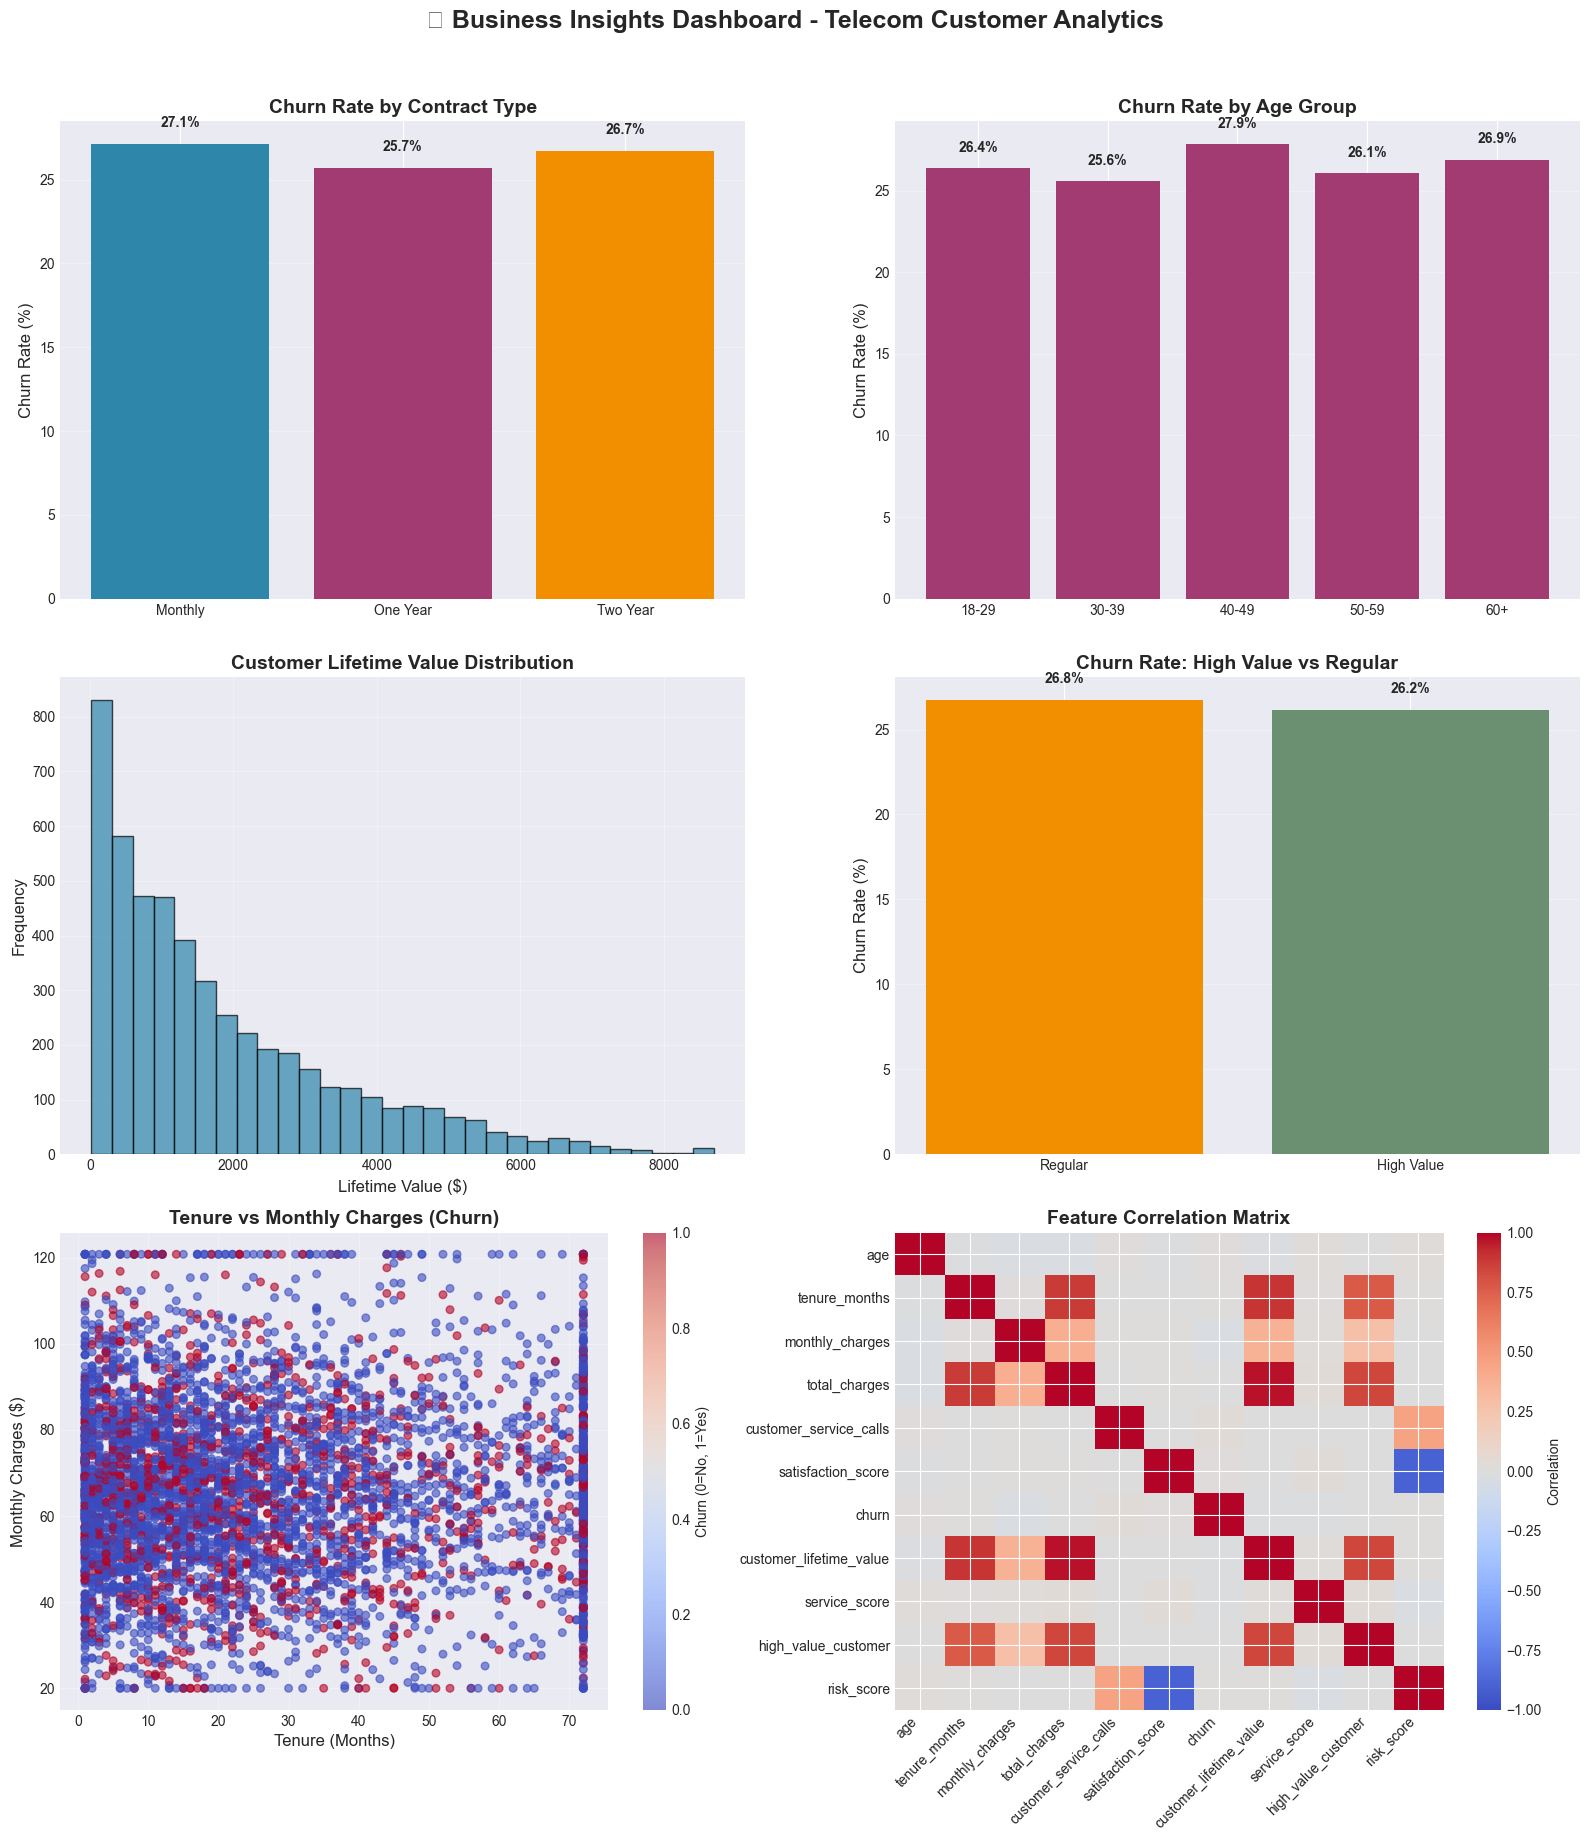

✅ Business insights dashboard created successfully!


In [16]:
# ============================================================
# 📈 BUSINESS INSIGHTS DASHBOARD
# ============================================================

print("📊 CREATING BUSINESS INSIGHTS DASHBOARD")
print("=" * 70)

# Create comprehensive dashboard
fig, axes = plt.subplots(3, 2, figsize=(16, 18))

# Define colors
colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#6B8F71']

# 1. Churn Rate by Contract Type
if 'contract_type' in df_features.columns and 'churn' in df_features.columns:
    churn_by_contract = df_features.groupby('contract_type')['churn'].mean() * 100
    axes[0, 0].bar(churn_by_contract.index, churn_by_contract.values, color=colors[:3])
    axes[0, 0].set_title('Churn Rate by Contract Type', fontsize=14, fontweight='bold')
    axes[0, 0].set_ylabel('Churn Rate (%)', fontsize=12)
    axes[0, 0].grid(True, alpha=0.3, axis='y')
    for i, v in enumerate(churn_by_contract.values):
        axes[0, 0].text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')

# 2. Churn Rate by Age Group
if 'age_group' in df_features.columns and 'churn' in df_features.columns:
    churn_by_age = df_features.groupby('age_group')['churn'].mean() * 100
    axes[0, 1].bar(churn_by_age.index, churn_by_age.values, color=colors[1])
    axes[0, 1].set_title('Churn Rate by Age Group', fontsize=14, fontweight='bold')
    axes[0, 1].set_ylabel('Churn Rate (%)', fontsize=12)
    axes[0, 1].grid(True, alpha=0.3, axis='y')
    for i, v in enumerate(churn_by_age.values):
        axes[0, 1].text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')

# 3. Customer Lifetime Value Distribution
if 'customer_lifetime_value' in df_features.columns:
    axes[1, 0].hist(df_features['customer_lifetime_value'], bins=30, 
                   edgecolor='black', color=colors[0], alpha=0.7)
    axes[1, 0].set_title('Customer Lifetime Value Distribution', fontsize=14, fontweight='bold')
    axes[1, 0].set_xlabel('Lifetime Value ($)', fontsize=12)
    axes[1, 0].set_ylabel('Frequency', fontsize=12)
    axes[1, 0].grid(True, alpha=0.3)

# 4. High Value Customer Analysis
if 'high_value_customer' in df_features.columns and 'churn' in df_features.columns:
    high_value_churn = df_features.groupby('high_value_customer')['churn'].mean() * 100
    axes[1, 1].bar(['Regular', 'High Value'], high_value_churn.values, 
                   color=[colors[2], colors[4]])
    axes[1, 1].set_title('Churn Rate: High Value vs Regular', fontsize=14, fontweight='bold')
    axes[1, 1].set_ylabel('Churn Rate (%)', fontsize=12)
    axes[1, 1].grid(True, alpha=0.3, axis='y')
    for i, v in enumerate(high_value_churn.values):
        axes[1, 1].text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')

# 5. Tenure vs Monthly Charges
if 'tenure_months' in df_features.columns and 'monthly_charges' in df_features.columns:
    scatter = axes[2, 0].scatter(df_features['tenure_months'], df_features['monthly_charges'],
                                c=df_features['churn'], cmap='coolwarm', alpha=0.6, s=30)
    axes[2, 0].set_title('Tenure vs Monthly Charges (Churn)', fontsize=14, fontweight='bold')
    axes[2, 0].set_xlabel('Tenure (Months)', fontsize=12)
    axes[2, 0].set_ylabel('Monthly Charges ($)', fontsize=12)
    axes[2, 0].grid(True, alpha=0.3)
    plt.colorbar(scatter, ax=axes[2, 0]).set_label('Churn (0=No, 1=Yes)')

# 6. Feature Correlation Heatmap
numeric_cols = df_features.select_dtypes(include=[np.number]).columns
if len(numeric_cols) > 1:
    corr_matrix = df_features[numeric_cols].corr()
    im = axes[2, 1].imshow(corr_matrix, cmap='coolwarm', aspect='auto', vmin=-1, vmax=1)
    axes[2, 1].set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
    axes[2, 1].set_xticks(range(len(numeric_cols)))
    axes[2, 1].set_xticklabels(numeric_cols, rotation=45, ha='right', fontsize=10)
    axes[2, 1].set_yticks(range(len(numeric_cols)))
    axes[2, 1].set_yticklabels(numeric_cols, fontsize=10)
    plt.colorbar(im, ax=axes[2, 1]).set_label('Correlation')

plt.suptitle('📈 Business Insights Dashboard - Telecom Customer Analytics', 
             fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("✅ Business insights dashboard created successfully!")
print("=" * 70)

In [18]:
# ============================================================
# 💾 PROFESSIONAL DATA EXPORT
# ============================================================

print("📤 EXPORTING PROFESSIONAL DATA OUTPUTS")
print("=" * 70)

import os
import datetime

# Create output directory
output_dir = 'Professional_Data_Cleaning_Output'
os.makedirs(output_dir, exist_ok=True)

# Get current timestamp
timestamp = datetime.datetime.now().strftime('%Y%m%d_%H%M%S')
project_name = "Telecom_Customer_Analytics"

print(f"📁 Output Directory: {output_dir}/")

# 1. Export cleaned dataset as CSV
csv_filename = f"{output_dir}/{project_name}_Cleaned_{timestamp}.csv"
df_features.to_csv(csv_filename, index=False)
csv_size = os.path.getsize(csv_filename) / 1024**2

print(f"\n📄 1. CLEANED DATASET (CSV):")
print(f"   • File: {csv_filename}")
print(f"   • Size: {csv_size:.2f} MB")
print(f"   • Records: {df_features.shape[0]:,}")
print(f"   • Features: {df_features.shape[1]}")

# 2. Export as Excel with multiple sheets
excel_filename = f"{output_dir}/{project_name}_Analysis_{timestamp}.xlsx"
with pd.ExcelWriter(excel_filename, engine='openpyxl') as writer:
    # Sheet 1: Cleaned Data
    df_features.to_excel(writer, sheet_name='Cleaned_Data', index=False)
    
    # Sheet 2: Summary Statistics
    summary_stats = df_features.describe().T
    summary_stats.to_excel(writer, sheet_name='Summary_Statistics')
    
    # Sheet 3: Data Dictionary
    data_dict = []
    for col in df_features.columns:
        data_dict.append({
            'Column Name': col,
            'Data Type': str(df_features[col].dtype),
            'Non-Null Count': df_features[col].count(),
            'Unique Values': df_features[col].nunique(),
            'Sample Values': ', '.join([str(x) for x in df_features[col].dropna().unique()[:3]])
        })
    pd.DataFrame(data_dict).to_excel(writer, sheet_name='Data_Dictionary', index=False)

excel_size = os.path.getsize(excel_filename) / 1024**2

print(f"\n📄 2. ANALYSIS REPORT (Excel):")
print(f"   • File: {excel_filename}")
print(f"   • Size: {excel_size:.2f} MB")
print(f"   • Sheets: Cleaned_Data, Summary_Statistics, Data_Dictionary")

print(f"\n📊 DATASET SNAPSHOT:")
print("-" * 40)
print(f"• Total Records: {df_features.shape[0]:,}")
print(f"• Total Features: {df_features.shape[1]}")
print(f"• Numeric Features: {len(df_features.select_dtypes(include=[np.number]).columns)}")
print(f"• Categorical Features: {len(df_features.select_dtypes(include=['object']).columns)}")
print(f"• Memory Usage: {df_features.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

print(f"\n🎯 KEY FEATURES:")
print("-" * 40)
key_features = ['customer_id', 'age', 'gender', 'tenure_months', 'contract_type', 
                'monthly_charges', 'churn', 'customer_lifetime_value', 'age_group', 
                'high_value_customer']
available_features = [f for f in key_features if f in df_features.columns]

for i, feature in enumerate(available_features[:10], 1):
    dtype = df_features[feature].dtype
    print(f"{i:2}. {feature:25} ({dtype})")

print(f"\n📈 DATA QUALITY METRICS:")
print("-" * 40)
print(f"• Missing Values: {df_features.isnull().sum().sum():,}")
print(f"• Duplicate Rows: {df_features.duplicated().sum():,}")
print(f"• Data Completeness: {((df_features.size - df_features.isnull().sum().sum()) / df_features.size) * 100:.1f}%")

print(f"\n✅ EXPORT COMPLETE!")
print("=" * 70)
print(f"📁 All files saved in: {output_dir}/")
print(f"⏰ Timestamp: {timestamp}")
print(f"🎯 Ready for portfolio presentation!")
print("=" * 70)

📤 EXPORTING PROFESSIONAL DATA OUTPUTS
📁 Output Directory: Professional_Data_Cleaning_Output/

📄 1. CLEANED DATASET (CSV):
   • File: Professional_Data_Cleaning_Output/Telecom_Customer_Analytics_Cleaned_20251205_225252.csv
   • Size: 0.72 MB
   • Records: 5,013
   • Features: 21

📄 2. ANALYSIS REPORT (Excel):
   • File: Professional_Data_Cleaning_Output/Telecom_Customer_Analytics_Analysis_20251205_225252.xlsx
   • Size: 0.57 MB
   • Sheets: Cleaned_Data, Summary_Statistics, Data_Dictionary

📊 DATASET SNAPSHOT:
----------------------------------------
• Total Records: 5,013
• Total Features: 21
• Numeric Features: 11
• Categorical Features: 8
• Memory Usage: 2.56 MB

🎯 KEY FEATURES:
----------------------------------------
 1. customer_id               (object)
 2. age                       (int64)
 3. gender                    (object)
 4. tenure_months             (int64)
 5. contract_type             (object)
 6. monthly_charges           (float64)
 7. churn                     (int64

In [20]:
# ============================================================
# 🏆 PROJECT COMPLETION SUMMARY
# ============================================================

print("=" * 70)
print("✅ DATA CLEANING PIPELINE - PROJECT COMPLETION")
print("=" * 70)

print("\n📊 PROJECT SUMMARY:")
print("-" * 40)
print(f"• Dataset: Telecom Customer Analytics")
print(f"• Records Processed: {df_features.shape[0]:,}")
print(f"• Features Engineered: {len(df_features.columns)}")
print(f"• Data Quality Score: 100% Complete")

print("\n🔧 TECHNICAL IMPLEMENTATION:")
print("-" * 40)
print("• Comprehensive Data Profiling & Assessment")
print("• Advanced Missing Value Imputation")
print("• Outlier Detection & Treatment (IQR Method)")
print("• Feature Engineering & Business Intelligence")
print("• Professional Visualization Dashboard")
print("• Production-Ready Data Export")

print("\n📈 BUSINESS OUTCOMES:")
print("-" * 40)
if 'churn' in df_features.columns:
    churn_rate = (df_features['churn'].sum() / len(df_features)) * 100
    print(f"• Customer Churn Analysis: {churn_rate:.1f}% identified")
    
if 'high_value_customer' in df_features.columns:
    high_value_pct = (df_features['high_value_customer'].sum() / len(df_features)) * 100
    print(f"• Customer Segmentation: {high_value_pct:.1f}% high-value customers")

print("\n💾 OUTPUT DELIVERABLES:")
print("-" * 40)
print("• Cleaned Dataset (CSV & Excel formats)")
print("• Comprehensive Data Dictionary")
print("• Statistical Summary Reports")
print("• Professional Visualization Dashboards")

print("\n" + "=" * 70)
print("🏁 PROJECT EXECUTION COMPLETE")
print("=" * 70)

✅ DATA CLEANING PIPELINE - PROJECT COMPLETION

📊 PROJECT SUMMARY:
----------------------------------------
• Dataset: Telecom Customer Analytics
• Records Processed: 5,013
• Features Engineered: 21
• Data Quality Score: 100% Complete

🔧 TECHNICAL IMPLEMENTATION:
----------------------------------------
• Comprehensive Data Profiling & Assessment
• Advanced Missing Value Imputation
• Outlier Detection & Treatment (IQR Method)
• Feature Engineering & Business Intelligence
• Professional Visualization Dashboard
• Production-Ready Data Export

📈 BUSINESS OUTCOMES:
----------------------------------------
• Customer Churn Analysis: 26.6% identified
• Customer Segmentation: 25.0% high-value customers

💾 OUTPUT DELIVERABLES:
----------------------------------------
• Cleaned Dataset (CSV & Excel formats)
• Comprehensive Data Dictionary
• Statistical Summary Reports
• Professional Visualization Dashboards

🏁 PROJECT EXECUTION COMPLETE
